Saved: IITJ_HomePage.txt (from https://www.iitj.ac.in...)
Saved: Academic_Regulations.txt (from https://iitj.ac.in/office-of-a...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/compute...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/materia...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/physics...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/mechani...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/bioscie...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/chemist...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/chemica...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/civil-a...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/electri...)
Saved: IITJ_Department_Data.txt (from https://www.iitj.ac.in/mathema...)
Saved: IITJ_Faculties_Profile.txt (from https://www.iitj.ac.in/People/...)
Saved: IITJ_Faculties_Profile.txt (from https://www.iitj.ac.in/P

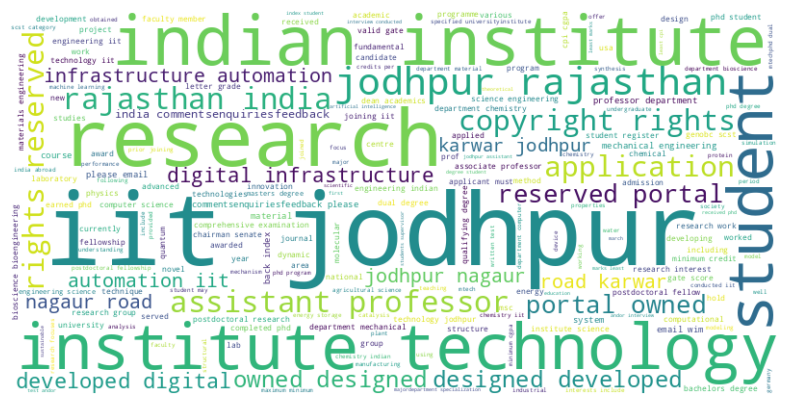

Word cloud saved: iitj_data_corpus/wordcloud.png


In [ ]:
import os
import requests
from bs4 import BeautifulSoup
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Download optional NLTK resources (only downloads when absent)
# punkt - - - rules of tokenizer to split text into words.
# punkttab -- updated tokenizers data (needed in newer NLTK versions)
# stopwords - usually English words that are frequent and should be eliminated (e.g. "the", "is" and "ands" etc.)

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

class DatasetPreparation:

    """
    HManages the entire pipe in the gathering, purification, and
    reports a NLP corpus created based on IIT Jodhpur web pages.

    Attributes:
        urls (list)             : List of target URLs to scrape.
        raw_data (list)         : Scraped raw page text.
        processed_tokens (list) : This is where the tokens are stored when preprocessed.
        output_dir (str)        : Directory to corpus files.
    """

    def __init__(self, urls):

        """
        Start the DatasetPreparation pipeline.

        Args:
            urls (list): List of URLs to scrape to get corpus data.
        """
        self.urls = urls
        self.raw_data = [] # Gathers unpolished text on each page.
        self.processed_tokens = [] # Gathers tokens following the processing
        self.output_dir = "iitj_data_corpus"  # All output files go here

    def collect_data(self):

        """
       Scraps all of the URLs in self.urls and stores the scraped text to
       one of four corpus files by the index position of the URL..

        File Assignment Logic:
            Index 0        → IITJ_HomePage.txt
            Index 1        → Academic_Regulations.txt
            Index 2–11     → IITJ_Department_Data.txt   (10 departments)
            Index 12+      → IITJ_Faculties_Profile.txt (faculty + other pages)

        It is possible to have several URLs added to the same file (e.g. all department
        pages build up in a single file, the behavior desired
        to construct an integrated corpus per category.

        Boilerplate Removal:
            <script>, <style>, <nav>, <footer>, <header> tags are taken away
            extracting text prior to noise removal by UI elements..

        Content Extraction:
            The extractable semantically meaningful tags only:
            <p>, <h1>, <h2>, <h3>, <li>
         """

       # Make output directory where not there
        print(f"Collecting data and creating directory: {self.output_dir}")
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)

        # Impersonate an actual browser, so as not to be blocked by the server
        headers = {'User-Agent': 'Mozilla/5.0'}

        for i, url in enumerate(self.urls):
            try:
                # Make an HTTP GET request with a 10-second timeout in order to prevent hanging
                response = requests.get(url, headers=headers, timeout=10)

                # Break up the HTML report into a BeautifulSoup tree
                soup = BeautifulSoup(response.content, 'html.parser')

                # --- Boilerplate Removal ---
                # Recurrently remove (irrevocably) non-content tags of the tree
                # their text is thus not extracted later on
                for s in soup(["script", "style", "nav", "footer", "header"]):
                    s.decompose()

                # --- Content Extraction ---
                # De-Semanticize only (headings, list items, paragraphs, etc.)
                chunks = soup.find_all(['p', 'h1', 'h2', 'h3', 'li'])

                # Combine all bits of text that have been extracted in one string on this page
                page_text = " ".join([c.get_text() for c in chunks])

                # Export Types of raw text to files
                if i==0:
                  filename = f"IITJ_HomePage.txt"
                elif i==1:
                  filename = f"Academic_Regulations.txt"
                elif i>=2 and i<=11:
                  filename = f"IITJ_Department_Data.txt"
                else:
                  filename = f"IITJ_Faculties_Profile.txt"
                filepath = os.path.join(self.output_dir, filename)

                # Append to file (do not overwrite) to have many URLs contributing
                # to the same, important, to the department and faculty files
                with open(filepath, "a", encoding="utf-8") as f:
                    f.write(page_text)

                self.raw_data.append(page_text)
                print(f"Saved: {filename} (from {url[:30]}...)")
            except Exception as e:
                print(f"Failed to scrape {url}: {e}")

    def preprocess(self):
        """
        Washes and de-scrapes the raw scraped text into a list of
        word-level meaningful tokens.

        These are the preprocessing Steps (in order):
        1. Concatenate all raw page texts together.
        2. DELETE non-alphabetic characters (numbers, punctuation marks, URLs, etc).
        3. Change to lower case in order to have homogenous vocabulary.
        4. NLTK tokenization into word tokens.
        5. Eliminate English stopwords (the, is, and, etc.).
        6. That is a small token (length of less than 2) which should be removed to minimize noise.

        Result:
          self.processed_tokens, a flat list of clean word tokens
          vocabulary training, word cloud, and Word2Vec training.
        """
        print("Preprocessing all documents...")
        # Paste all pages that you have scraped together
        combined_text = " ".join(self.raw_data)

        # Stripe out all but alphabetic characters and blank spaces
        # This removes numbers, punctuations, URLs, special symbols, etc.
        clean_text = re.sub(r'[^a-zA-Z\s]', '', combined_text).lower()

        # Tokenize: divide the clean text into word tokens
        # word_tokenize is more tolerant of contractions, and edge cases, than .split()
        tokens = word_tokenize(clean_text)

        # Load stopword list of English into a set of NLTK
        stop_words = set(stopwords.words('english'))
        # You can add iit and jodhpur to the stop words, to see other topics
        # but in most cases we store them with school-clouds
        self.processed_tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    def report_and_save_stats(self):

        """
        Calculates corpus statistics, creates vocabulary (csv),
        and creates / stores an image of a word cloud.

        Statistics Reported:
          - Number of totals saved in output directory.txt files.
          - Total sum of preprocessed tokens.
          - Unique vocabulary size

        Outputs:
          vocabulary.csv -- list of the unique tokens sorted.
          wordcloud.png - diagram of the most common tokens.
        """
        print("\nGenerating Statistics & CSV...")

        # Construct sorted unique vocabulary out of the processed token list
        vocab = sorted(list(set(self.processed_tokens)))

        # Save vocabulary to CSV
        df = pd.DataFrame(vocab, columns=["Unique_Words"])
        df.to_csv(os.path.join(self.output_dir, "vocabulary.csv"), index=False)

        # --- Print Dataset Statistics ---
        print("-" * 35)
        print(f"Files saved in:    {self.output_dir}/")
        print(f"Total Documents:   {len([f for f in os.listdir(self.output_dir) if f.endswith('.txt')])}")
        print(f"Total Tokens:      {len(self.processed_tokens)}")
        print(f"Unique Vocab:      {len(vocab)}")
        print("-" * 35)

        # Word Cloud
        wc_text = " ".join(self.processed_tokens)
        wc = WordCloud(width=800, height=400, background_color='white').generate(wc_text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        wc_path = os.path.join(self.output_dir, "wordcloud.png")
        plt.savefig(wc_path, bbox_inches='tight')
        plt.show()
        print(f"Word cloud saved: {wc_path}")

# --- Execution ---
if __name__ == "__main__":
    target_urls = [
        "https://www.iitj.ac.in",
        "https://iitj.ac.in/office-of-academics/en/academic-regulations",
        "https://www.iitj.ac.in/computer-science-engineering",
        "https://www.iitj.ac.in/materials-engineering/en/materials-engineering",
        "https://www.iitj.ac.in/physics",
        "https://www.iitj.ac.in/mechanical-engineering",
        "https://www.iitj.ac.in/bioscience-bioengineering",
        "https://www.iitj.ac.in/chemistry/en/chemistry",
        "https://www.iitj.ac.in/chemical-engineering",
        "https://www.iitj.ac.in/civil-and-infrastructure-engineering",
        "https://www.iitj.ac.in/electrical-engineering",
        "https://www.iitj.ac.in/mathematics",
        "https://www.iitj.ac.in/People/Profile/da9e767c-2519-4d9d-b214-a2e6672fa28f",
        "https://www.iitj.ac.in/People/Profile/f7ba55d2-3e1c-4642-97a2-c26b180cf629",
        "https://www.iitj.ac.in/People/Profile/6046b822-6242-435c-837a-63e43c5bbddf",
        "https://www.iitj.ac.in/People/Profile/7e5bf1a9-f93b-4297-ab96-aaf3f4c3a152",
        "https://www.iitj.ac.in/People/Profile/a2b7bd88-e8af-4f2a-8ef5-cf3f93a0205c",
        "https://www.iitj.ac.in/People/Profile/982ad0e4-22d8-453d-b568-e8375cce2ed8",
        "https://www.iitj.ac.in/People/Profile/54b44158-467d-4b18-8520-76960a8ac361",
        "https://www.iitj.ac.in/People/Profile/3e0f631c-b113-40a8-a913-dad7e38302ba",
        "https://www.iitj.ac.in/People/Profile/2b96a56f-8f69-4882-bcf7-6082206e2da6",
        "https://www.iitj.ac.in/People/Profile/57115a9d-9098-43b0-97ff-abb76d0c3b8f",
        "https://www.iitj.ac.in/People/Profile/154d45e3-aaff-4931-bfc3-5a2cd143c9a8",
        "https://www.iitj.ac.in/People/Profile/d51ea0be-c509-43b8-ac52-814dc89af3fa",
        "https://www.iitj.ac.in/People/Profile/b4630c99-3331-4c2d-b5f4-1584a677bafe",
        "https://www.iitj.ac.in/People/Profile/4535d2a6-1ff9-4b6a-8cb9-d7138cdf1d76",
        "https://www.iitj.ac.in/People/Profile/2b242a78-aa3f-4402-ba12-86b5c46dd19f",
        "https://www.iitj.ac.in/People/Profile/08508feb-b781-4394-a232-e865315f907f",
        "https://www.iitj.ac.in/People/Profile/db19f434-f125-47b6-8df8-1619d3dc05ff",
        "https://www.iitj.ac.in/People/Profile/1df3e1b9-d190-4bd5-b0ea-c4153adbb811",
        "https://www.iitj.ac.in/People/Profile/5af7aa8f-d9e3-461b-8b3e-6949788deec8",
        "https://www.iitj.ac.in/People/Profile/a769cd20-e6dd-47e8-b783-d639fe0f03a3",
        "https://www.iitj.ac.in/People/Profile/8a873ad0-7817-4f84-9ee5-9f3c183ff8a3",
        "https://www.iitj.ac.in/People/Profile/2caea0cd-8a3e-461d-b233-d79d179835a0",
        "https://www.iitj.ac.in/People/Profile/fa184434-70e8-4b5c-88e5-357322c13ecb",
        "https://www.iitj.ac.in/People/Profile/ef32ebf7-68e0-499e-8e95-e396ed9cb4c2",
        "https://www.iitj.ac.in/People/Profile/67f2594e-2c56-480b-b97e-f60f0f912ecb",
        "https://www.iitj.ac.in/People/Profile/9a79909e-8fec-4e9c-9939-495eddcc4800",
        "https://www.iitj.ac.in/People/Profile/f0d96526-8dee-4420-bf5c-f74d10b92d29",
        "https://www.iitj.ac.in/People/Profile/76dd83e8-8105-4c01-81ef-872f670c0819",
        "https://www.iitj.ac.in/People/Profile/d6be896f-eae8-404c-8127-044afcc600ff",
        "https://www.iitj.ac.in/People/Profile/7549ee81-dafc-42ff-96cf-9ca60bbd0e6e",
        "https://www.iitj.ac.in/People/Profile/3861d159-f61d-461c-84ec-fdd89c65ce94",
        "https://www.iitj.ac.in/People/Profile/b8df6ff7-b2a4-44f5-9892-483e9956bcd2",
        "https://www.iitj.ac.in/People/Profile/106d9783-5898-4fd9-93a7-1ff3c7250679",
        "https://www.iitj.ac.in/People/Profile/6a9116d7-b55d-487a-a446-a721c47b9f25",
        "https://www.iitj.ac.in/People/Profile/9cb7d7d9-2ddc-499c-b473-fc5b4bfba1d1",
        "https://www.iitj.ac.in/People/Profile/e848de48-43e2-4c22-98bf-3013549cf25f",
        "https://www.iitj.ac.in/People/Profile/25b387b3-eb46-49f4-9902-5e7f89d16c4c",
        "https://www.iitj.ac.in/People/Profile/1f19679b-7d1f-4a27-8add-f81a1ca8a9ae",
        "https://www.iitj.ac.in/People/Profile/55236026-5920-42f2-ab5f-d4e9d5b42ad3",
        "https://www.iitj.ac.in/People/Profile/3d071c94-7f86-4b19-a1bb-ae354243fed7",
        "https://www.iitj.ac.in/People/Profile/008f60d7-fff8-4c80-a17b-b8c030903a17",
        "https://www.iitj.ac.in/People/Profile/e204f033-9f86-4656-b37d-115fd2bb3f2c",
        "https://www.iitj.ac.in/People/Profile/6db18428-8744-4a5a-a833-6327d9fe8b1f",
        "https://www.iitj.ac.in/People/Profile/31e6c4da-7e70-4037-a3fc-bbdc0eb7c31c",
        "https://www.iitj.ac.in/People/Profile/78a1293c-c392-413f-a4b6-574c733704e5",
        "https://www.iitj.ac.in/People/Profile/abdbc3fd-3cbd-4313-9486-898c6501ff38",
        "https://www.iitj.ac.in/People/Profile/722e42bd-fc72-4cba-9716-dda9aec11ee0",
        "https://www.iitj.ac.in/People/Profile/95fdee68-c15f-4af1-bddf-81848e0d403d",
        "https://www.iitj.ac.in/People/Profile/6432b1c9-5437-405e-b76b-ce944e490b5a",
        "https://www.iitj.ac.in/People/Profile/6cadecfd-06f8-47db-ad43-eb188e004814",
        "https://www.iitj.ac.in/People/Profile/f2329e77-fa84-47d6-a2e0-6411ee287390",
        "https://www.iitj.ac.in/People/Profile/d030eb4e-eed0-45d8-9246-9fdf47768840",
        "https://www.iitj.ac.in/People/Profile/ff0be18d-bc39-49b8-b01c-eb8627ef7a98",
        "https://www.iitj.ac.in/People/Profile/62056caf-6eea-420a-a71b-1ddc8f023ff2",
        "https://www.iitj.ac.in/People/Profile/60368e43-099d-460b-9825-e2109d475a5d",
        "https://www.iitj.ac.in/People/Profile/786b7cb6-f463-48cb-96ba-395ef1853ecc",
        "https://www.iitj.ac.in/People/Profile/2a1d5bcc-231c-42e2-9420-140260977b74",
        "https://www.iitj.ac.in/People/Profile/9eaa5e9a-d5fa-446c-ae2e-9f733346e19c",
        "https://www.iitj.ac.in/People/Profile/d742ae96-d6a9-413c-b187-838be229b599",
        "https://www.iitj.ac.in/People/Profile/b5d0ced7-bfcf-4e23-90c6-825932f6994f",
        "https://www.iitj.ac.in/People/Profile/2b249475-2e78-47d9-81a4-b5b2cb67cad3",
        "https://www.iitj.ac.in/People/Profile/5f42b716-6e43-426e-9a7a-e3b595aad513",
        "https://www.iitj.ac.in/People/Profile/ff437570-52ce-4e3a-9ba8-46719a2e02f2",
        "https://www.iitj.ac.in/People/Profile/09759489-697b-41f4-866d-c6fa9429e6d6",
        "https://www.iitj.ac.in/People/Profile/81bffe38-3214-4f20-bb67-006f095d6dab",
        "https://www.iitj.ac.in/People/Profile/89e48bd7-0bf0-458e-bd58-384d20e4e280",
        "https://www.iitj.ac.in/People/Profile/a7d36280-c7d7-4146-b911-6eda86293bd6",
        "https://www.iitj.ac.in/People/Profile/9de5eb3e-18f5-4179-8f4b-56d9cb7d7c13",
        "https://www.iitj.ac.in/People/Profile/fc4753f7-09b1-4664-bb89-1333f53ab502",
        "https://www.iitj.ac.in/People/Profile/0a35133e-df53-421a-86ef-1ef9a327fbe2",
        "https://www.iitj.ac.in/People/Profile/acbabe2f-fde5-4542-bd4b-645b450b32b0",
        "https://www.iitj.ac.in/People/Profile/430f7be3-95d2-4f60-9547-8488def6c02a",
        "https://www.iitj.ac.in/People/Profile/d22ce5ab-e4b8-41e2-8ad1-224d0199e231",
        "https://www.iitj.ac.in/People/Profile/1cf4dea1-95f5-4df3-98c8-58dafdc29fbb",
        "https://www.iitj.ac.in/People/Profile/8da833ca-ddf0-4573-a255-2ec5ff1cad0e",
        "https://www.iitj.ac.in/People/Profile/3c808055-5a08-4ab4-93b4-d4b93907a615",
        "https://www.iitj.ac.in/People/Profile/6efb8e3a-4a9a-462e-a672-176a5b7ebbca",
        "https://www.iitj.ac.in/People/Profile/db26b245-e616-4195-ba92-29252e3f66dc",
        "https://www.iitj.ac.in/People/Profile/ba433f28-e067-48f5-b1c3-e0ccbda9eff6",
        "https://www.iitj.ac.in/People/Profile/85cc96f5-12a4-4b76-9c2a-35d7180f912b",
        "https://www.iitj.ac.in/People/Profile/97b9be38-8cf7-42b0-becc-03c8be076400",
        "https://www.iitj.ac.in/People/Profile/ab8b7203-7570-42d4-bf27-90e07b057c4d",
        "https://www.iitj.ac.in/People/Profile/dcba7c86-0698-466e-b17a-9504b80c2dd7",
        "https://www.iitj.ac.in/People/Profile/9d24c0d9-e4a5-4e51-8560-6e1bfdb9e5c2",
        "https://www.iitj.ac.in/People/Profile/61b50115-865c-4e6a-be34-60e8d22ff7d4",
        "https://www.iitj.ac.in/People/Profile/080ba052-fdd7-4b24-b8db-61d50aaf7bd3",
        "https://www.iitj.ac.in/People/Profile/cace6668-e83a-4fea-a396-3b675ec90585",
        "https://www.iitj.ac.in/People/Profile/112f8dc8-2296-4a92-bcfd-8332cf7c2cae",
        "https://www.iitj.ac.in/People/Profile/b539dfb5-c236-4925-a700-fe5630445070",
        "https://www.iitj.ac.in/People/Profile/6bd86035-a7bb-45d5-979a-5d5b2929efe1",
        "https://www.iitj.ac.in/People/Profile/0e400705-34cd-474b-90c6-37ef91ab1229",
        "https://www.iitj.ac.in/People/Profile/ff3faff6-7d32-46fd-8e73-47742ffb6d3d",
        "https://www.iitj.ac.in/People/Profile/c5ba64d1-c8e8-4005-a2a3-3bbb86a35ce8",
        "https://www.iitj.ac.in/People/Profile/2bb6d539-3d38-410e-9d4d-9e5e3636dd8d",
        "https://www.iitj.ac.in/People/Profile/a829a339-c3c5-4e99-8e2d-6f5e35cbbe7b",
        "https://www.iitj.ac.in/People/Profile/9ed8a7e2-dbb3-43c1-9b05-53c2e38a9399",
        "https://www.iitj.ac.in/People/Profile/15ffef73-7177-4e78-952a-3f5266724e06",
        "https://www.iitj.ac.in/People/Profile/9d3ba817-6299-455f-8db6-a1b2fbd3ae0d",
        "https://www.iitj.ac.in/People/Profile/fffda3f7-7a59-45b9-b171-13b0badfd73c",
        "https://www.iitj.ac.in/People/Profile/f86bb4d8-3dbc-47b1-aa9b-9ea03f68b27c",
        "https://www.iitj.ac.in/People/Profile/da2bfc42-c11a-46b6-b766-9ecdcffd4c63",
        "https://www.iitj.ac.in/People/Profile/8fb3af46-842a-4bf7-b092-35cdc423225b",
        "https://www.iitj.ac.in/People/Profile/89567437-f752-419e-bd58-343d5eda7dd8",
        "https://www.iitj.ac.in/People/Profile/c624948a-b47d-44ed-80d6-c7114fe17943",
        "https://www.iitj.ac.in/People/Profile/e9793af3-6d4f-4560-8489-2c256912a72a",
        "https://www.iitj.ac.in/People/Profile/c7aa696c-0f3d-48aa-ad32-eeb189bdca60",
        "https://www.iitj.ac.in/People/Profile/9d7c7c5b-4ddf-487e-a00c-ab2c5878b9a4",
        "https://www.iitj.ac.in/People/Profile/bc795393-557c-4140-8c14-932a5953a6a1",
        "https://www.iitj.ac.in/People/Profile/214803fd-cce9-456f-ae72-ef3f65eb700e",
        "https://www.iitj.ac.in/People/Profile/68f50f33-2fc9-4bd7-84c7-35383ad1f25e",
        "https://www.iitj.ac.in/People/Profile/d91efa87-e52b-427e-9bde-1bd4c70da809",
        "https://www.iitj.ac.in/People/Profile/52db0e41-e9cb-48da-a073-82fdb8e34c8e",
        "https://www.iitj.ac.in/People/Profile/c4e78878-de8a-4b54-b32a-513cd47e5f9f",
        "https://www.iitj.ac.in/People/Profile/fcf966fb-01fe-4660-9fb3-fa692911a86a",
        "https://www.iitj.ac.in/People/Profile/704e3335-4472-41d5-977b-8894ad72725a",
        "https://www.iitj.ac.in/People/Profile/14173529-10a4-4cc2-98e9-1b8c7c3f2808",
        "https://www.iitj.ac.in/People/Profile/ec8b858c-7122-4046-8597-5a7871a10258",
        "http://iitj.ac.in/People/Profile/fc707e09-5a46-4cb2-917e-41bb890224a1",
        "https://www.iitj.ac.in/People/Profile/5b8588ed-46d8-4538-a65b-ade8a504afd3",
        "https://www.iitj.ac.in/People/Profile/2b0dd7d6-caec-4c45-a2ec-c71c1e22fe69",
        "https://www.iitj.ac.in/People/Profile/4e083fc9-2fd4-4be3-a783-af62a1e99733",
        "https://www.iitj.ac.in/People/Profile/cbfae589-0b31-43d8-8a49-4990247e8628",
        "https://www.iitj.ac.in/People/Profile/baf1bbab-ae95-4ab5-b876-9235446dcfa2",
        "https://www.iitj.ac.in/People/Profile/bd7768c2-8b59-45e2-a469-6a7682f5bb77",
        "https://www.iitj.ac.in/People/Profile/02cb8d8a-d546-4de8-8a3e-7dfe304f0c0b",
        "https://www.iitj.ac.in/People/Profile/4197664f-3d41-4bf0-a5e3-ecc15f4a35b1",
        "https://www.iitj.ac.in/master-of-technology/en/eligibility",
        "https://www.iitj.ac.in/bachelor-of-technology/en/registration-academic-session",
        "https://www.iitj.ac.in/schools/en/eligibility-criteria-and-selection-process",
    ]

    task = DatasetPreparation(target_urls)
    task.collect_data() # Scrape and save raw text files
    task.preprocess() # Clean and tokenize all text
    task.report_and_save_stats() # Print stats, save CSV, show word cloud